Hilber Matrix simulation 1




--- Error Analysis ---
Left extreme error  (log10(alpha)=-16.00): 1.075877e+00
Right extreme error (log10(alpha)=5.00): 9.999963e-01

Minimum error: 4.395921e-01
Occurs at log10(alpha) = -15.436242
Equivalent alpha = 3.662338e-16
Maximum alpha tested: 1.000000e+05
Execution time: 0.1291 seconds


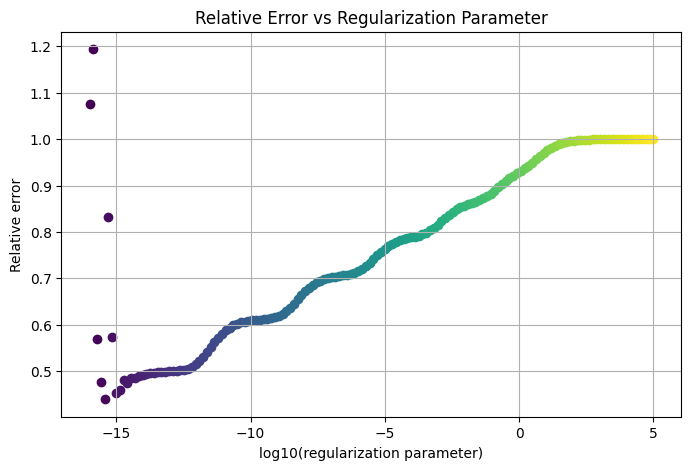

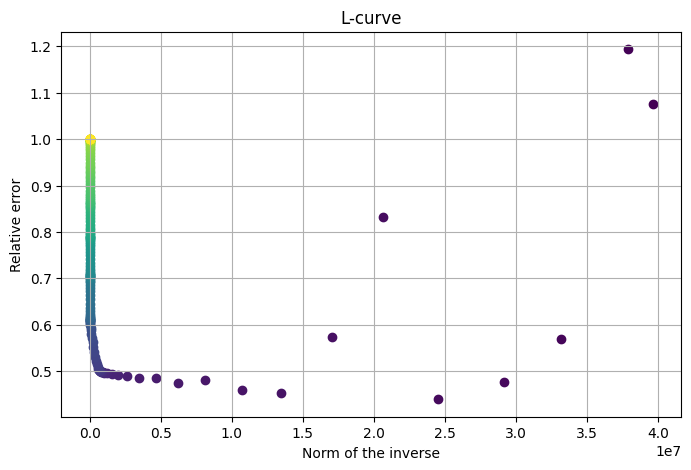

Images saved successfully.


In [ ]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def hilbert_matrix(n):
    return scipy.linalg.hilbert(n)

def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I

def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    H = hilbert_matrix(n)

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []
        trial_norms = []

        for _ in range(num_trials):

            r = 10**(-3)

            A = H + 0 * J

            alpha = 10**reg

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ H - I) / np.linalg.norm(I)

            norm_inv = np.linalg.norm(A_inv_tik)

            trial_errors.append(error)
            trial_norms.append(norm_inv)

        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return errors, norms


if __name__ == "__main__":

    start_time = time.time()

    # Tamaño de la matriz
    n = 8

    # RANGO MODIFICADO: ahora hasta x = 5
    # (antes era hasta 0)
    regularization_values = np.linspace(-16, 5, 150)

    errors, norms = compute_errors(n, regularization_values)

    # Convertir a arrays
    errors = np.array(errors)
    norms = np.array(norms)
    regularization_values = np.array(regularization_values)

    # Análisis de errores

    error_left = errors[0]
    error_right = errors[-1]

    min_index = np.argmin(errors)

    min_error = errors[min_index]

    optimal_reg_log = regularization_values[min_index]

    optimal_alpha = 10**optimal_reg_log

    print("\n--- Error Analysis ---")

    print(
        f"Left extreme error  (log10(alpha)={regularization_values[0]:.2f}): "
        f"{error_left:.6e}"
    )

    print(
        f"Right extreme error (log10(alpha)={regularization_values[-1]:.2f}): "
        f"{error_right:.6e}"
    )

    print(f"\nMinimum error: {min_error:.6e}")

    print(f"Occurs at log10(alpha) = {optimal_reg_log:.6f}")

    print(f"Equivalent alpha = {optimal_alpha:.6e}")

    print(
        f"Maximum alpha tested: {10**regularization_values[-1]:.6e}"
    )

    execution_time = time.time() - start_time

    print(f"Execution time: {execution_time:.4f} seconds")

    colors = cm.viridis(
        np.linspace(0, 1, len(regularization_values))
    )

    # --------- FIGURA 1 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            regularization_values[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("log10(regularization parameter)")

    plt.ylabel("Relative error")

    plt.title(
        "Relative Error vs Regularization Parameter"
    )

    plt.grid()

    plt.savefig(
        "relative_error.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    # --------- FIGURA 2 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            norms[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("Norm of the inverse")

    plt.ylabel("Relative error")

    plt.title("L-curve")

    plt.grid()

    plt.savefig(
        "L_curve.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    print("Images saved successfully.")

Save figures

In [ ]:
from google.colab import files

files.download("relative_error.png")
files.download("L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 2




--- Error Analysis ---
Left extreme error (log10(alpha)=-18.00): 1.335452e+05
Right extreme error (log10(alpha)=5.00): 9.999986e-01

Minimum error: 8.546516e-01
Occurs at log10(alpha) = -12.573034
Equivalent alpha = 2.672799e-13
Execution time: 0.0853 seconds


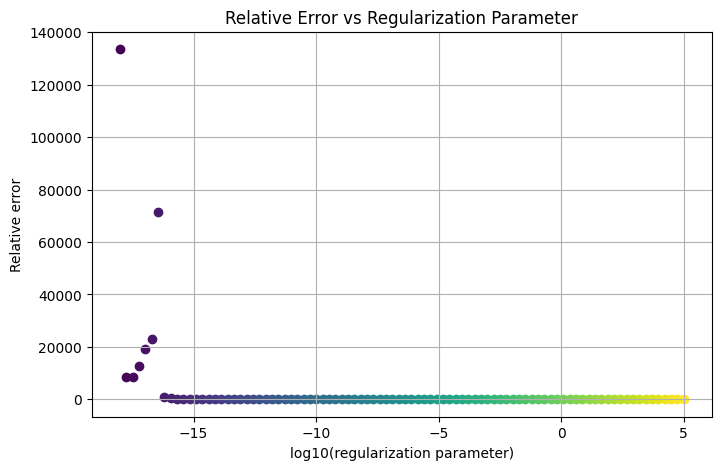

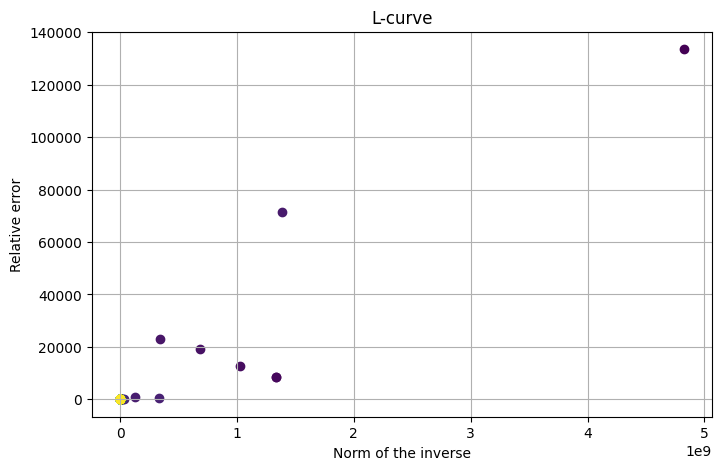

Images saved successfully in the Colab environment.


In [ ]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

# Para descargar archivos en Colab
from google.colab import files


def hilbert_matrix(n):
    return scipy.linalg.hilbert(n)


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I


def compute_errors(n, regularization_values, num_trials=10):

    errors = []
    norms = []

    H = hilbert_matrix(n)

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []
        trial_norms = []

        for _ in range(num_trials):

            r = 10**(-3)

            A = H + 0 * J

            alpha = 10**reg

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ H - I) / np.linalg.norm(I)

            norm_inv = np.linalg.norm(A_inv_tik)

            trial_errors.append(error)
            trial_norms.append(norm_inv)

        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return errors, norms


if __name__ == "__main__":

    start_time = time.time()

    n = 30

    # 🔴 RANGO MODIFICADO (ahora hasta x=5)
    regularization_values = np.linspace(-18, 5, 90)

    errors, norms = compute_errors(n, regularization_values)

    # Convertir a arrays
    errors = np.array(errors)
    norms = np.array(norms)
    regularization_values = np.array(regularization_values)

    # --------- ANÁLISIS ---------

    error_left = errors[0]
    error_right = errors[-1]

    min_index = np.argmin(errors)

    min_error = errors[min_index]

    optimal_reg_log = regularization_values[min_index]

    optimal_alpha = 10**optimal_reg_log

    print("\n--- Error Analysis ---")

    print(
        f"Left extreme error "
        f"(log10(alpha)={regularization_values[0]:.2f}): "
        f"{error_left:.6e}"
    )

    print(
        f"Right extreme error "
        f"(log10(alpha)={regularization_values[-1]:.2f}): "
        f"{error_right:.6e}"
    )

    print(f"\nMinimum error: {min_error:.6e}")

    print(f"Occurs at log10(alpha) = {optimal_reg_log:.6f}")

    print(f"Equivalent alpha = {optimal_alpha:.6e}")

    execution_time = time.time() - start_time

    print(f"Execution time: {execution_time:.4f} seconds")

    colors = cm.viridis(
        np.linspace(0, 1, len(regularization_values))
    )

    # --------- FIGURA 1 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            regularization_values[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("log10(regularization parameter)")

    plt.ylabel("Relative error")

    plt.title("Relative Error vs Regularization Parameter")

    plt.grid()

    plt.savefig(
        "relative_error.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    # --------- FIGURA 2 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            norms[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("Norm of the inverse")

    plt.ylabel("Relative error")

    plt.title("L-curve")

    plt.grid()

    plt.savefig(
        "L_curve.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    print("Images saved successfully in the Colab environment.")


Save figures

In [ ]:
from google.colab import files

files.download("relative_error.png")
files.download("L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 3


--- Error Analysis ---
Left extreme error  (log10(alpha)=-18.00): 2.271921e+10
Right extreme error (log10(alpha)=5.00): 9.999999e-01

Minimum error: 9.941872e-01
Occurs at log10(alpha) = -9.730337
Equivalent alpha = 1.860642e-10
Maximum alpha tested: 1.000000e+05
Execution time: 334.8277 seconds


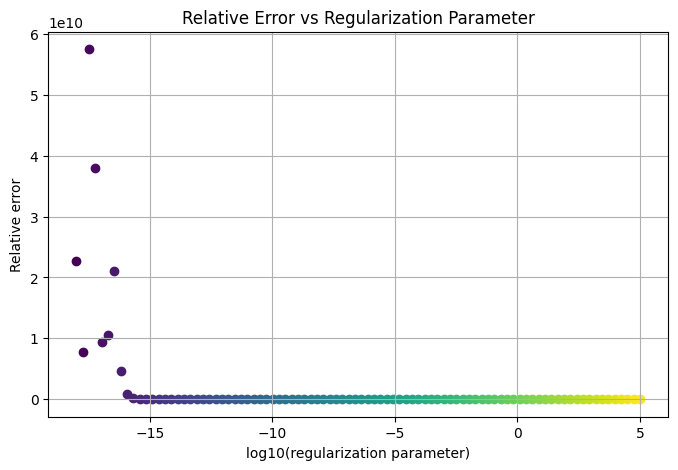

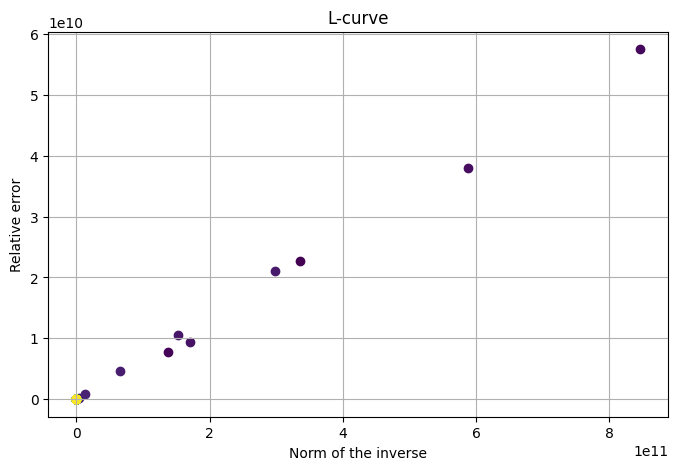

Images saved successfully.


In [ ]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def hilbert_matrix(n):
    return scipy.linalg.hilbert(n)

def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I

def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    H = hilbert_matrix(n)

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:

        trial_errors = []
        trial_norms = []

        for _ in range(num_trials):

            r = 10**(-3)

            A = H + 0 * J

            alpha = 10**reg

            A_inv_tik = inverse_by_tikhonov(A, alpha)

            error = np.linalg.norm(A_inv_tik @ H - I) / np.linalg.norm(I)

            norm_inv = np.linalg.norm(A_inv_tik)

            trial_errors.append(error)
            trial_norms.append(norm_inv)

        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return errors, norms


if __name__ == "__main__":

    start_time = time.time()

    # Tamaño de la matriz
    n = 1000

    # RANGO MODIFICADO: ahora hasta x = 5
    # (antes era hasta 0)
    regularization_values = np.linspace(-18, 5, 90)

    errors, norms = compute_errors(n, regularization_values)

    # Convertir a arrays
    errors = np.array(errors)
    norms = np.array(norms)
    regularization_values = np.array(regularization_values)

    # Análisis de errores

    error_left = errors[0]
    error_right = errors[-1]

    min_index = np.argmin(errors)

    min_error = errors[min_index]

    optimal_reg_log = regularization_values[min_index]

    optimal_alpha = 10**optimal_reg_log

    print("\n--- Error Analysis ---")

    print(
        f"Left extreme error  (log10(alpha)={regularization_values[0]:.2f}): "
        f"{error_left:.6e}"
    )

    print(
        f"Right extreme error (log10(alpha)={regularization_values[-1]:.2f}): "
        f"{error_right:.6e}"
    )

    print(f"\nMinimum error: {min_error:.6e}")

    print(f"Occurs at log10(alpha) = {optimal_reg_log:.6f}")

    print(f"Equivalent alpha = {optimal_alpha:.6e}")

    print(
        f"Maximum alpha tested: {10**regularization_values[-1]:.6e}"
    )

    execution_time = time.time() - start_time

    print(f"Execution time: {execution_time:.4f} seconds")

    colors = cm.viridis(
        np.linspace(0, 1, len(regularization_values))
    )

    # --------- FIGURA 1 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            regularization_values[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("log10(regularization parameter)")

    plt.ylabel("Relative error")

    plt.title(
        "Relative Error vs Regularization Parameter"
    )

    plt.grid()

    plt.savefig(
        "relative_error.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    # --------- FIGURA 2 ---------

    plt.figure(figsize=(8, 5))

    for i in range(len(regularization_values)):

        plt.scatter(
            norms[i],
            errors[i],
            color=colors[i]
        )

    plt.xlabel("Norm of the inverse")

    plt.ylabel("Relative error")

    plt.title("L-curve")

    plt.grid()

    plt.savefig(
        "L_curve.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    print("Images saved successfully.")

Save figures


In [ ]:
from google.colab import files

files.download("relative_error.png")
files.download("L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Correlation matrix


Simulation 1


Correlation matrix:
[[ 1.         -0.06563818  0.68851889]
 [-0.06563818  1.          0.67846134]
 [ 0.68851889  0.67846134  1.        ]]
Condition number: 68883253286.6491

Execution time: 0.0354 seconds

--- Optimal Regularization ---
Minimum relative error: 5.773503e-01
log10(alpha_opt) = -10.101010
alpha_opt = 7.924829e-11


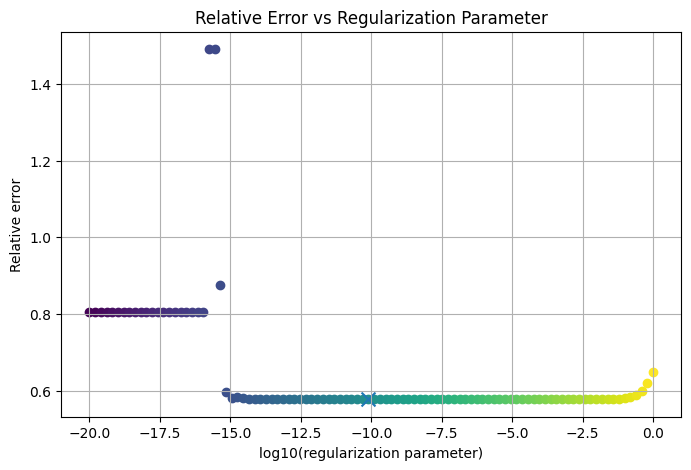

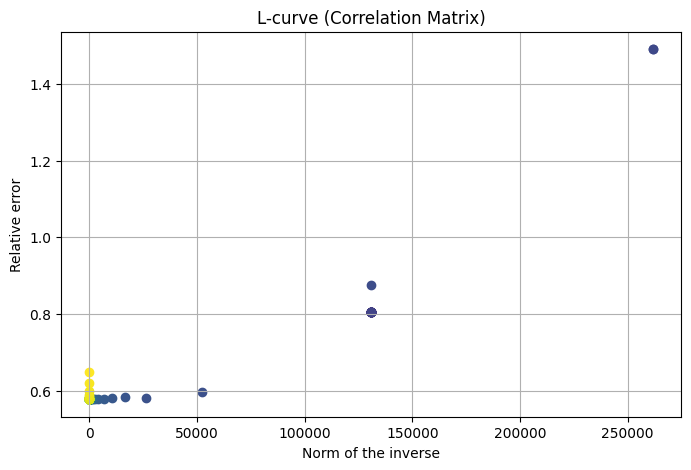


Images saved successfully in the Colab environment.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def generate_correlated_data(n_samples=1000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    X2 = np.random.randn(n_samples)
    epsilon = noise * np.random.randn(n_samples)
    X3 = X1 + X2 + epsilon  # Strong linear dependence

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix

def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I

def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    C = generate_correlated_data()
    print("Correlation matrix:")
    print(C)
    print("Condition number:", np.linalg.cond(C))

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        trial_norms = []
        for _ in range(num_trials):
            r = 10**(-3)
            A = C + 0* J
            A_inv_tik = inverse_by_tikhonov(A, 10**reg)
            error = np.linalg.norm(A_inv_tik @ C - I) / np.linalg.norm(I)
            norm_inv = np.linalg.norm(A_inv_tik)
            trial_errors.append(error)
            trial_norms.append(norm_inv)
        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return np.array(errors), np.array(norms)


if __name__ == "__main__":
    start_time = time.time()

    n = 3
    regularization_values = np.linspace(-20, 0, 100)
    errors, norms = compute_errors(n, regularization_values)

    execution_time = time.time() - start_time
    print(f"\nExecution time: {execution_time:.4f} seconds")

    # --------- Cálculo del mínimo ---------
    min_index = np.argmin(errors)
    min_error = errors[min_index]
    optimal_log_alpha = regularization_values[min_index]
    optimal_alpha = 10**optimal_log_alpha

    print("\n--- Optimal Regularization ---")
    print(f"Minimum relative error: {min_error:.6e}")
    print(f"log10(alpha_opt) = {optimal_log_alpha:.6f}")
    print(f"alpha_opt = {optimal_alpha:.6e}")

    colors = cm.viridis(np.linspace(0, 1, len(regularization_values)))

    # --------- FIGURA 1 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(regularization_values[i], errors[i], color=colors[i])
    plt.scatter(optimal_log_alpha, min_error, marker='x', s=100)  # Marca el mínimo
    plt.xlabel("log10(regularization parameter)")
    plt.ylabel("Relative error")
    plt.title("Relative Error vs Regularization Parameter")
    plt.grid()

    plt.savefig("correlation_relative_error.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # --------- FIGURA 2 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(norms[i], errors[i], color=colors[i])
    plt.xlabel("Norm of the inverse")
    plt.ylabel("Relative error")
    plt.title("L-curve (Correlation Matrix)")
    plt.grid()

    plt.savefig("correlation_L_curve.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print("\nImages saved successfully in the Colab environment.")

Save figures

In [ ]:
from google.colab import files
files.download("correlation_relative_error.png")
files.download("correlation_L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 2


Noise level: 0.04
Average condition number: 2.338e+04
log10(optimal alpha): -4.1414
Optimal alpha: 7.221e-05
Minimum relative error: 5.777e-01

Noise level: 0.05
Average condition number: 3.447e+03
log10(optimal alpha): -3.3333
Optimal alpha: 4.642e-04
Minimum relative error: 5.776e-01

Noise level: 0.08
Average condition number: 1.095e+03
log10(optimal alpha): -3.1313
Optimal alpha: 7.391e-04
Minimum relative error: 5.765e-01

Noise level: 0.1
Average condition number: 7.128e+02
log10(optimal alpha): -2.9293
Optimal alpha: 1.177e-03
Minimum relative error: 5.762e-01

Noise level: 0.2
Average condition number: 1.918e+02
log10(optimal alpha): -2.6263
Optimal alpha: 2.364e-03
Minimum relative error: 5.660e-01

Figure saved as: relative_error_vs_regularization.png


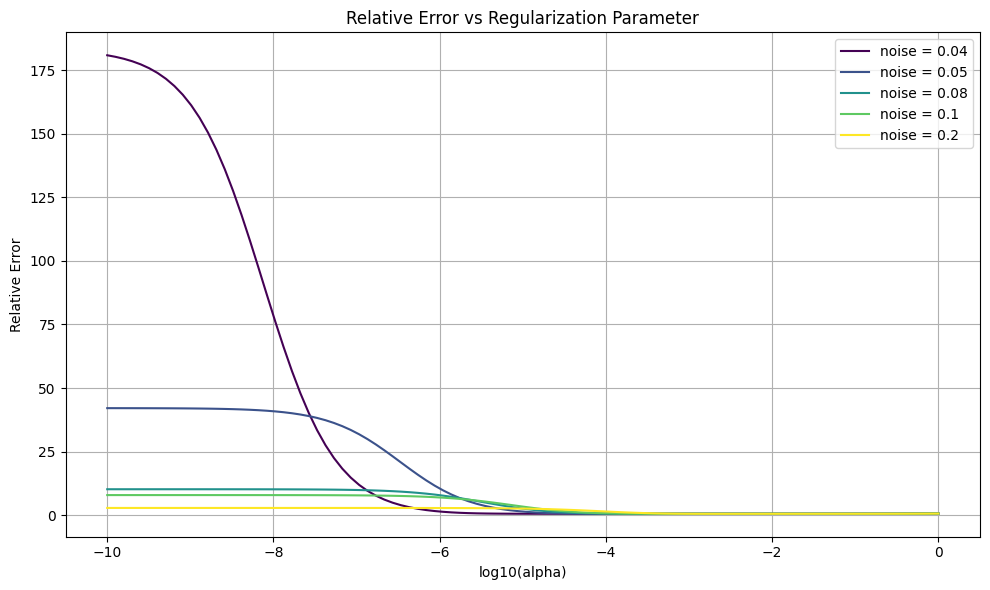

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generate_correlated_data(n_samples=1000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    X2 = np.random.randn(n_samples)
    epsilon = noise * np.random.randn(n_samples)
    X3 = X1 + X2 + epsilon  # Strong linear dependence

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T


def compute_errors(n, regularization_values, noise, num_trials=10):
    errors = []
    cond_numbers = []

    # Matriz original
    C_org = generate_correlated_data(noise=noise)
    # Matriz para experimentar con ruido
    C = generate_correlated_data(noise=noise)

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        trial_conds = []
        alpha = 10**reg

        for _ in range(num_trials):
            r = 1e-3
            A = C + r * J
            A_inv_tik = inverse_by_tikhonov(A, alpha)
            error = np.linalg.norm(A_inv_tik @ C_org - I) / np.linalg.norm(I)
            trial_errors.append(error)

            # Guardar número de condición de A
            trial_conds.append(np.linalg.cond(A))

        # Promedio sobre los trials
        errors.append(np.mean(trial_errors))
        cond_numbers.append(np.mean(trial_conds))

    return np.array(errors), np.array(cond_numbers)


if __name__ == "__main__":
    n = 3
    regularization_values = np.linspace(-10, 0, 100)
    noise_levels = [0.04, 0.05, 0.08, 0.1, 0.2]
    colors = cm.viridis(np.linspace(0, 1, len(noise_levels)))

    plt.figure(figsize=(10, 6))

    for i, noise in enumerate(noise_levels):
        errors, conds = compute_errors(n, regularization_values, noise=noise)

        min_index = np.argmin(errors)
        optimal_log_alpha = regularization_values[min_index]
        optimal_alpha = 10**optimal_log_alpha
        min_error = errors[min_index]

        # Imprimir resumen
        print(f"Noise level: {noise}")
        print(f"Average condition number: {np.mean(conds):.3e}")
        print(f"log10(optimal alpha): {optimal_log_alpha:.4f}")
        print(f"Optimal alpha: {optimal_alpha:.3e}")
        print(f"Minimum relative error: {min_error:.3e}\n")

        # Guardar tabla para exportar a LaTeX si quieres
        # Puedes descomentar estas líneas para ver la tabla completa
        # import pandas as pd
        # df = pd.DataFrame({
        #     'log10_alpha': regularization_values,
        #     'relative_error': errors,
        #     'condition_number': conds
        # })
        # print(df)

        plt.plot(regularization_values, errors,
                 label=f"noise = {noise}",
                 color=colors[i])

    plt.xlabel("log10(alpha)")
    plt.ylabel("Relative Error")
    plt.title("Relative Error vs Regularization Parameter")
    plt.grid()
    plt.legend()
    plt.tight_layout()

    # 🔹 Guardar imagen
    filename = "relative_error_vs_regularization.png"
    plt.savefig(filename, dpi=300)
    print(f"Figure saved as: {filename}")

    plt.show()

Save figures

In [ ]:
from google.colab import files
files.download("relative_error_vs_regularization.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 3


Correlation matrix:
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
Condition number: 163719775638.2317

--- Optimal Regularization ---
Minimum relative error: 8.164966e-01
log10(alpha_opt) = -10.474747
alpha_opt = 3.351603e-11


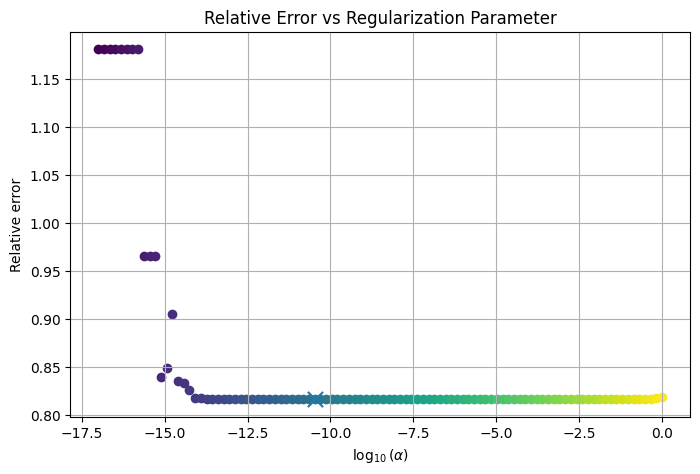

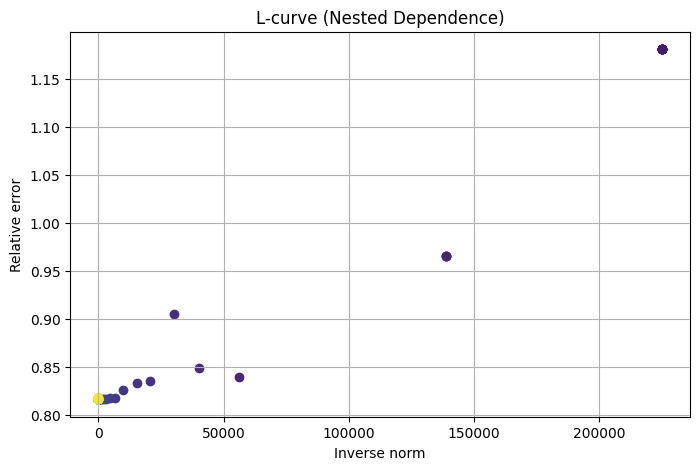


Execution time: 3.6818 seconds

Images saved successfully in the Colab environment.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

def generate_correlated_data(n_samples=1000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    epsilon1 = noise * np.random.randn(n_samples)
    X2 = X1 + epsilon1
    epsilon2 = noise * np.random.randn(n_samples)
    X3 = X1 + X2 + epsilon2

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T @ I


def compute_errors(n, regularization_values, num_trials=10):
    errors = []
    norms = []

    C = generate_correlated_data()
    print("Correlation matrix:")
    print(C)
    print("Condition number:", np.linalg.cond(C))

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        trial_norms = []
        for _ in range(num_trials):
            r = 10**(-3)
            A = C + 0 * J
            A_inv_tik = inverse_by_tikhonov(A, 10**reg)
            error = np.linalg.norm(A_inv_tik @ C - I) / np.linalg.norm(I)
            norm_inv = np.linalg.norm(A_inv_tik)
            trial_errors.append(error)
            trial_norms.append(norm_inv)
        errors.append(np.mean(trial_errors))
        norms.append(np.mean(trial_norms))

    return np.array(errors), np.array(norms)


if __name__ == "__main__":
    start_time = time.time()

    n = 3
    regularization_values = np.linspace(-17, 0, 100)
    errors, norms = compute_errors(n, regularization_values)

    # --------- Cálculo del mínimo ---------
    min_index = np.argmin(errors)
    min_error = errors[min_index]
    optimal_log_alpha = regularization_values[min_index]
    optimal_alpha = 10**optimal_log_alpha

    print("\n--- Optimal Regularization ---")
    print(f"Minimum relative error: {min_error:.6e}")
    print(f"log10(alpha_opt) = {optimal_log_alpha:.6f}")
    print(f"alpha_opt = {optimal_alpha:.6e}")

    colors = cm.viridis(np.linspace(0, 1, len(regularization_values)))

    # --------- FIGURA 1 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(regularization_values[i], errors[i], color=colors[i])
    plt.scatter(optimal_log_alpha, min_error, marker='x', s=120)
    plt.xlabel(r"$\log_{10}(\alpha)$")
    plt.ylabel("Relative error")
    plt.title("Relative Error vs Regularization Parameter")
    plt.grid()

    plt.savefig("correlation_nested_relative_error.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # --------- FIGURA 2 ---------
    plt.figure(figsize=(8, 5))
    for i in range(len(regularization_values)):
        plt.scatter(norms[i], errors[i], color=colors[i])
    plt.xlabel("Inverse norm")
    plt.ylabel("Relative error")
    plt.title("L-curve (Nested Dependence)")
    plt.grid()

    plt.savefig("correlation_nested_L_curve.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    end_time = time.time()
    print(f"\nExecution time: {end_time - start_time:.4f} seconds")
    print("\nImages saved successfully in the Colab environment.")

Save figures

In [ ]:
from google.colab import files
files.download("correlation_nested_relative_error.png")
files.download("correlation_nested_L_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation 4



Noise level: 0.04
Condition number: 1.210e+04
log10(optimal alpha): -2.5758
Optimal alpha: 2.656e-03
Minimum relative error: 8.165e-01


Noise level: 0.05
Condition number: 6.650e+03
log10(optimal alpha): -2.2727
Optimal alpha: 5.337e-03
Minimum relative error: 8.165e-01


Noise level: 0.08
Condition number: 2.640e+03
log10(optimal alpha): -1.8182
Optimal alpha: 1.520e-02
Minimum relative error: 8.165e-01


Noise level: 0.1
Condition number: 1.956e+03
log10(optimal alpha): -1.6667
Optimal alpha: 2.154e-02
Minimum relative error: 8.165e-01


Noise level: 0.2
Condition number: 4.999e+02
log10(optimal alpha): -1.2121
Optimal alpha: 6.136e-02
Minimum relative error: 8.165e-01

Figure saved as: relative_error_vs_regularization_noise_levels.png


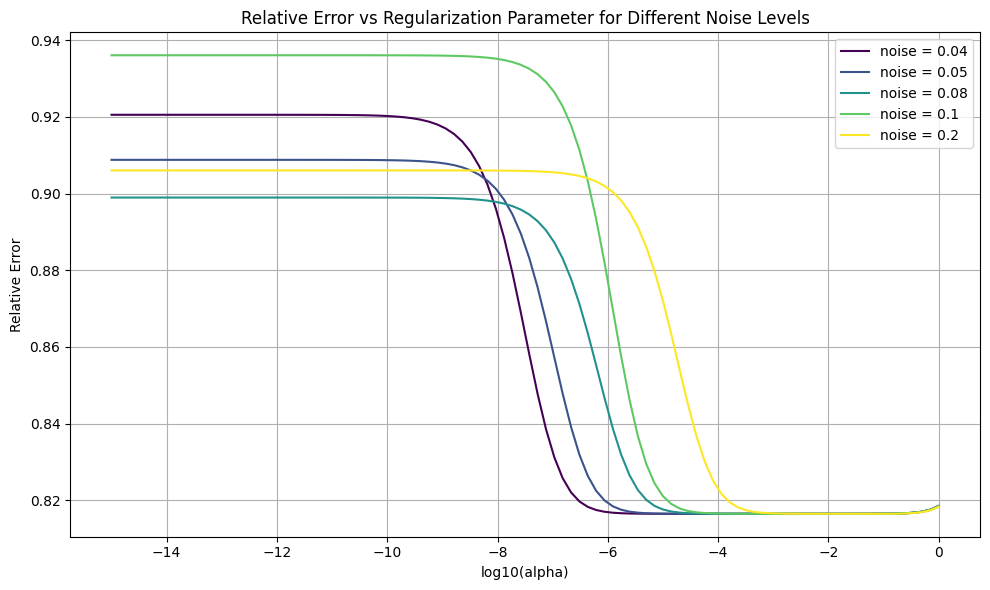

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def generate_correlated_data(n_samples=2000, noise=0.00001, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.randn(n_samples)
    epsilon1 = noise * np.random.randn(n_samples)
    X2 = X1 + epsilon1
    epsilon2 = noise * np.random.randn(n_samples)
    X3 = X1 + X2 + epsilon2

    data = np.vstack((X1, X2, X3)).T
    correlation_matrix = np.corrcoef(data, rowvar=False)
    return correlation_matrix


def inverse_by_tikhonov(A, alpha):
    n = A.shape[0]
    I = np.eye(n)
    return np.linalg.inv(A.T @ A + alpha * I) @ A.T


def compute_errors(n, regularization_values, noise, num_trials=10):
    errors = []

    C_org = generate_correlated_data()
    C = generate_correlated_data(noise=noise)

    cond_number = np.linalg.cond(C)
    print(f"\nNoise level: {noise}")
    print(f"Condition number: {cond_number:.3e}")

    K = np.ones((n, n))
    J = np.random.rand(n, n) - 0.5 * K
    I = np.eye(n)

    for reg in regularization_values:
        trial_errors = []
        alpha = 10**reg

        for _ in range(num_trials):
            r = 10**(-3)
            A = C + 0* J
            A_inv_tik = inverse_by_tikhonov(A, alpha)
            error = np.linalg.norm(A_inv_tik @ C_org - I) / np.linalg.norm(I)
            trial_errors.append(error)

        errors.append(np.mean(trial_errors))

    return np.array(errors)


if __name__ == "__main__":
    n = 3
    regularization_values = np.linspace(-15, 0, 100)
    noise_levels = [0.04, 0.05, 0.08, 0.1, 0.2]

    colors = cm.viridis(np.linspace(0, 1, len(noise_levels)))

    plt.figure(figsize=(10, 6))

    for i, noise in enumerate(noise_levels):
        errors = compute_errors(n, regularization_values, noise=noise)

        min_index = np.argmin(errors)
        optimal_log_alpha = regularization_values[min_index]
        optimal_alpha = 10**optimal_log_alpha
        min_error = errors[min_index]

        print(f"log10(optimal alpha): {optimal_log_alpha:.4f}")
        print(f"Optimal alpha: {optimal_alpha:.3e}")
        print(f"Minimum relative error: {min_error:.3e}\n")

        plt.plot(
            regularization_values,
            errors,
            label=f"noise = {noise}",
            color=colors[i]
        )

    plt.xlabel("log10(alpha)")
    plt.ylabel("Relative Error")
    plt.title("Relative Error vs Regularization Parameter for Different Noise Levels")

    plt.grid()
    plt.legend()
    plt.tight_layout()

    # Guardar figura
    filename = "relative_error_vs_regularization_noise_levels.png"
    plt.savefig(filename, dpi=300)

    print(f"Figure saved as: {filename}")

    plt.show()

Save figures


In [ ]:
from google.colab import files
files.download("relative_error_vs_regularization_noise_levels.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>